# Assignment 1

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt


df = pd.read_csv("../data/Oryctolagus_cuniculus.csv")

C:\Users\naimi\AppData\Local\Temp\ipykernel_6488\2470697763.py:5: DtypeWarning: Columns (0: Oryctolagus cuniculus) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/Oryctolagus_cuniculus.csv")


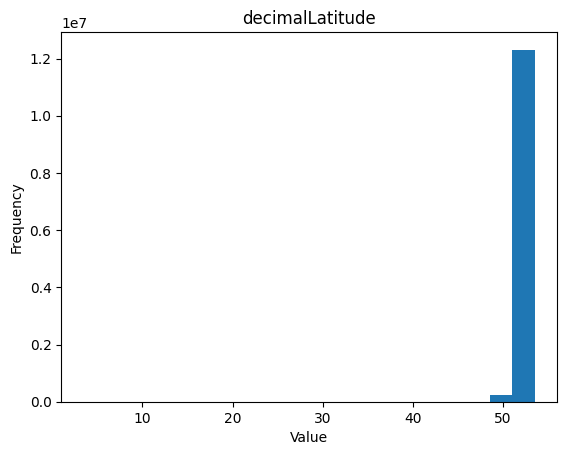

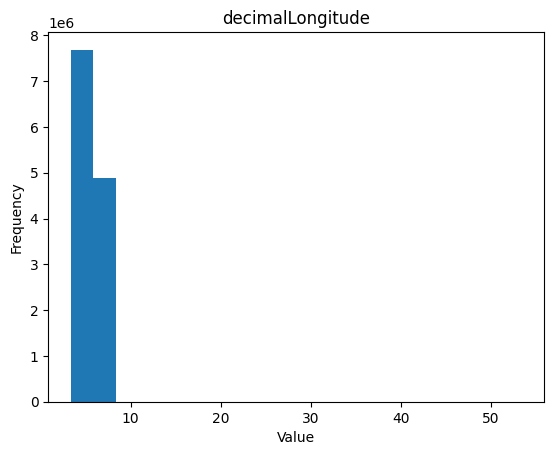

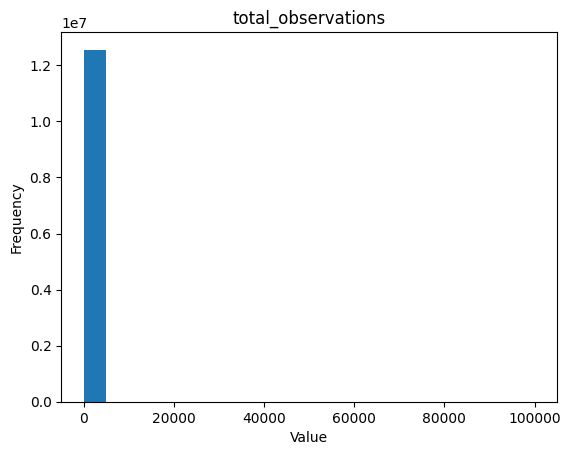

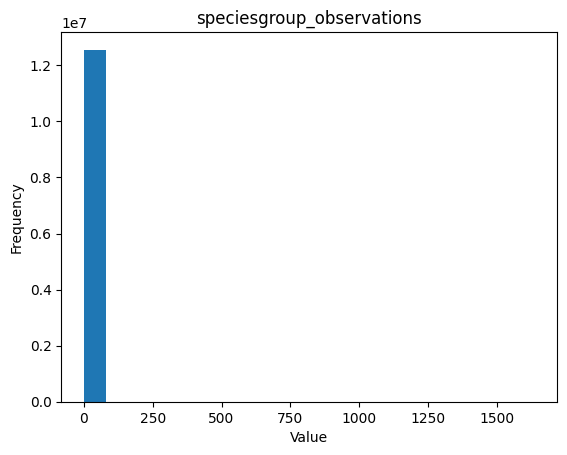

In [2]:
for col in df.describe().columns:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

In [9]:
avg = df['SalePrice'].mean()
std = df['SalePrice'].std()
df['SalePrice Zscore'] = (df['SalePrice'] - avg) / std
len(df.loc[(df['SalePrice Zscore'] <-3) | (df['SalePrice Zscore'] > 3)])

45

In [10]:
IQR = (df.describe()['SalePrice']['75%'] - df.describe()['SalePrice']['25%'])
low = df.describe()['SalePrice']['25%'] - (1.5 * IQR)
high = df.describe()['SalePrice']['75%'] + (1.5 * IQR)
len(df.loc[(df['SalePrice'] < low) | (df['SalePrice'] > high)])

137

# Assignment 2

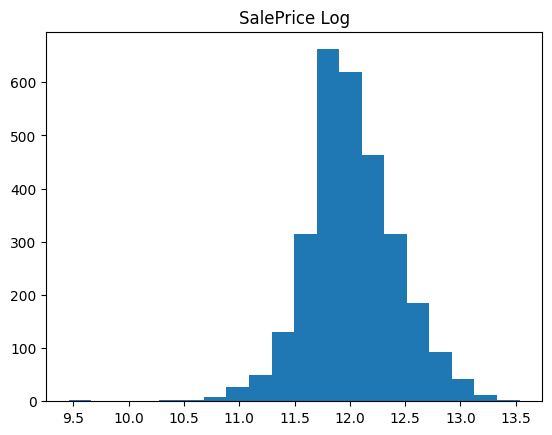

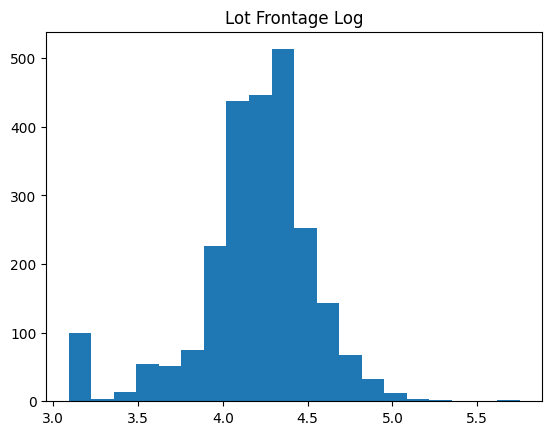

In [17]:
import numpy as np
df['saleprice_log'] = df['SalePrice'].apply(lambda x: np.log(x))
plt.hist(df['saleprice_log'], bins=20)
plt.title('SalePrice Log')  
plt.show()
df['lot_frontage_log'] = df['Lot Frontage'].apply(lambda x: np.log(x))
plt.hist(df['lot_frontage_log'], bins=20)
plt.title('Lot Frontage Log')
plt.show()

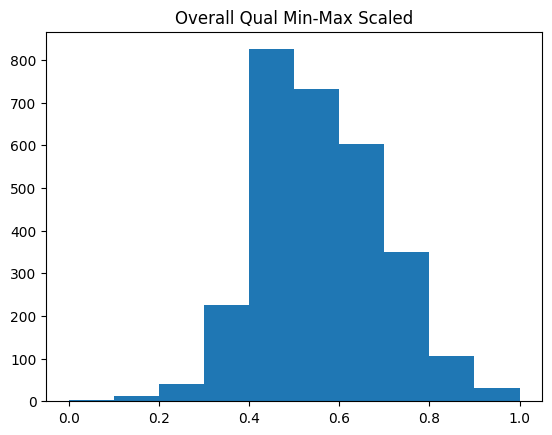

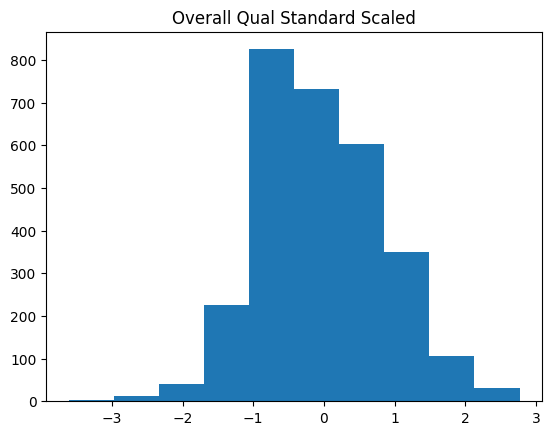

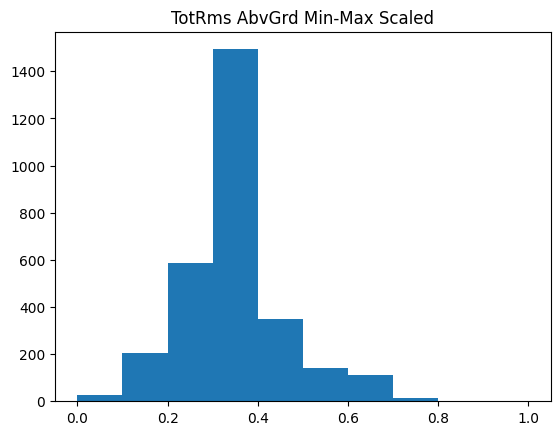

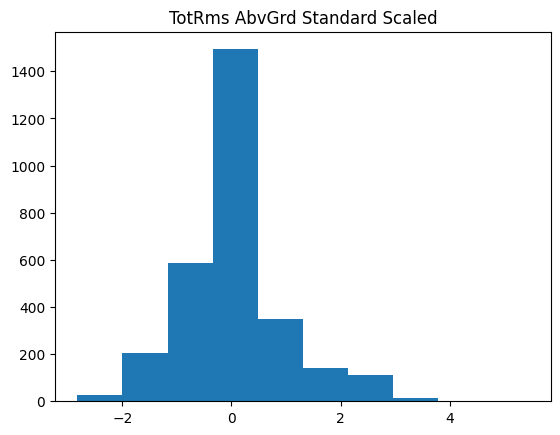

In [22]:
# min max scaler
from sklearn.preprocessing import MinMaxScaler, StandardScaler


df['overall_qual_minmax'] = MinMaxScaler().fit_transform(df[['Overall Qual']])
plt.hist(df['overall_qual_minmax'], bins=10)    
plt.title('Overall Qual Min-Max Scaled')
plt.show()

df['overall_qual_standard'] = StandardScaler().fit_transform(df[['Overall Qual']])
plt.hist(df['overall_qual_standard'], bins=10)    
plt.title('Overall Qual Standard Scaled')
plt.show()

df['TotRms AbvGrd_minmax'] = MinMaxScaler().fit_transform(df[['TotRms AbvGrd']])
df['TotRms AbvGrd_standard'] = StandardScaler().fit_transform(df[['TotRms AbvGrd']])
plt.hist(df['TotRms AbvGrd_minmax'], bins=10)
plt.title('TotRms AbvGrd Min-Max Scaled')
plt.show()

plt.hist(df['TotRms AbvGrd_standard'], bins=10)
plt.title('TotRms AbvGrd Standard Scaled')
plt.show()



# Assignment 3

In [23]:
df = pd.read_csv('DSAI_week_2.csv', sep=';', index_col=0)

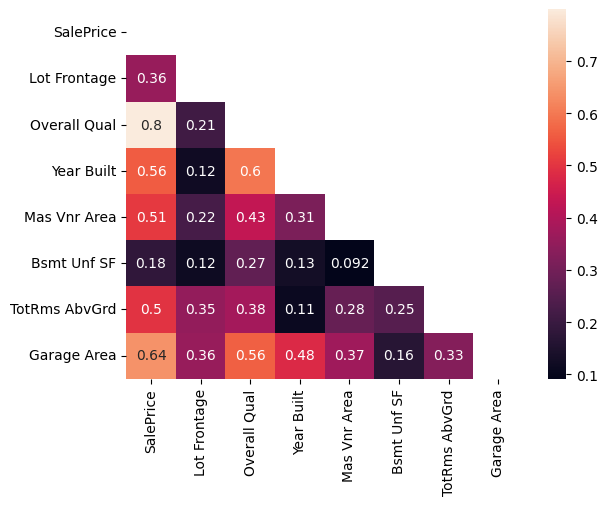

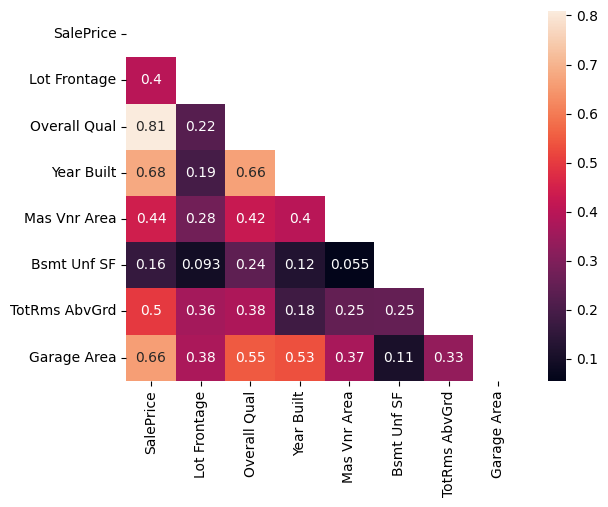

In [60]:
import seaborn as sns
# Display only half of the correlation matrix
mask = np.triu(np.ones_like(df.corr(numeric_only=True, method='pearson'), dtype=bool))
sns.heatmap(df.corr(numeric_only=True, method='pearson'), annot=True, mask=mask)
plt.show()

sns.heatmap(df.corr(numeric_only=True, method='spearman'), annot=True, mask=mask)
plt.show()

In [27]:
df.drop(columns=['Garage Cars'], inplace=True)

In [30]:
!pip install dcor

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   -------------------------- ------------- 1.8/2.8 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 9.9 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   --- ------------------------------------ 3.4/38.1 MB 15.9 MB/s eta 0:00:03
   ------ --------------------------------- 6.3/38.1 MB 14.6 MB/s eta 0:00:03
   ---------- ----------------------------- 9.7/38.1 MB 15.1 MB/s eta 0:00:02
   -------------- ------------------------- 13.4/38.1 MB 15.7 MB/s eta 0:00:02
   ---------------- ----------------------- 15.7/38.1 MB 14.9 MB/s eta 0:00:02
   ------------------ --------------------- 17.6/38.1 MB 14.3 MB/s eta 0:00:02
   --------------------- ------------------ 20.2/38.1 MB 13.7 MB/s eta 0:00:02
   ------------------------ --------------- 23.6/38.1 MB 14.1 MB/s eta 0:00:02
   ---------------------------- ----------- 27.0/38.1 MB 14.4 MB/s eta 0:00:01
   -


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\KokRemco\AppData\Local\Programs\Python\Python313\Lib\site-packages\dcor\_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) readonly array(int64, 1d, C), readonly array(int64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(
c:\Users\KokRemco\AppData\Local\Programs\Python\Python313\Lib\site-packages\dcor\_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) readonly array(int64, 1d, C), readonly array(float64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(
c:\Users\KokRemco\AppData\Local\Programs\Python\Python313\Lib\site-packages\dcor\_fast_dcov_avl.py:554: UserWarning: Falling back to uncompile

<Axes: ylabel='Column'>

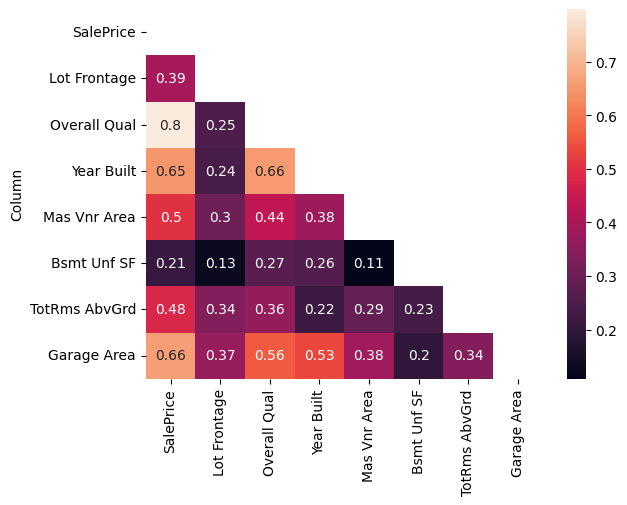

In [61]:
import dcor

df_numeric = df.select_dtypes(include=[np.number])
dfy = df_numeric.dropna()


dfp = pd.DataFrame({'Column' : columns})
dfp[columns] = np.nan
for column in columns:
    for column2 in columns:
        value = dcor.distance_correlation(dfy[column], dfy[column2])
        dfp.loc[dfp['Column'] == column2, column] = value

# Mask the upper triangle
mask = np.triu(np.ones_like(dfp[columns], dtype=bool))

sns.heatmap(dfp.set_index('Column'), annot=True, mask=mask)